# Step 4: Predictive Modeling – Salary Prediction

In this step, we build machine learning models to predict salaries based on:
- Experience level
- Job title
- Company location
- Remote ratio
- Employment type

We’ll:
1. Prepare features and encode categorical variables.
2. Train baseline models (Linear Regression).
3. Train advanced models (Random Forest, XGBoost).
4. Evaluate performance using RMSE and R².
5. Interpret results with feature importance and SHAP values.

## Baseline Model - Linear Regression

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/processed/ds_salaries_2025_clean.csv")

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import numpy as np

# Select features
features = ['experience_level', 'job_title', 'company_location', 'remote_ratio', 'employment_type']
target = 'salary_in_usd'

X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define categorical and numeric columns
cat_cols = ['experience_level', 'job_title', 'company_location', 'employment_type']
num_cols = ['remote_ratio']

# Preprocessor (One-hot for categorical, passthrough for numeric)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

In [5]:
# Pipeline: preprocessing + linear regression
linreg = Pipeline(steps=[('preprocessor', preprocessor),
                         ('model', LinearRegression())])

linreg.fit(X_train, y_train)

y_pred = linreg.predict(X_test)

print("Linear Regression Performance:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

ValueError: For a sparse output, all columns should be a numeric or convertible to a numeric.

## Advanced Models (Random Forest & XGBoost)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Random Forest
rf = Pipeline(steps=[('preprocessor', preprocessor),
                     ('model', RandomForestRegressor(n_estimators=200, random_state=42))])

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("Random Forest Performance:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R²:", r2_score(y_test, rf_pred))

# XGBoost
xgb = Pipeline(steps=[('preprocessor', preprocessor),
                      ('model', XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=8, random_state=42))])

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGBoost Performance:")
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R²:", r2_score(y_test, xgb_pred))

Random Forest Performance:
RMSE: 65639.20806591594
R²: 0.28810615283416796
XGBoost Performance:
RMSE: 65246.15523311337
R²: 0.2966063810817149


## Feature Importance

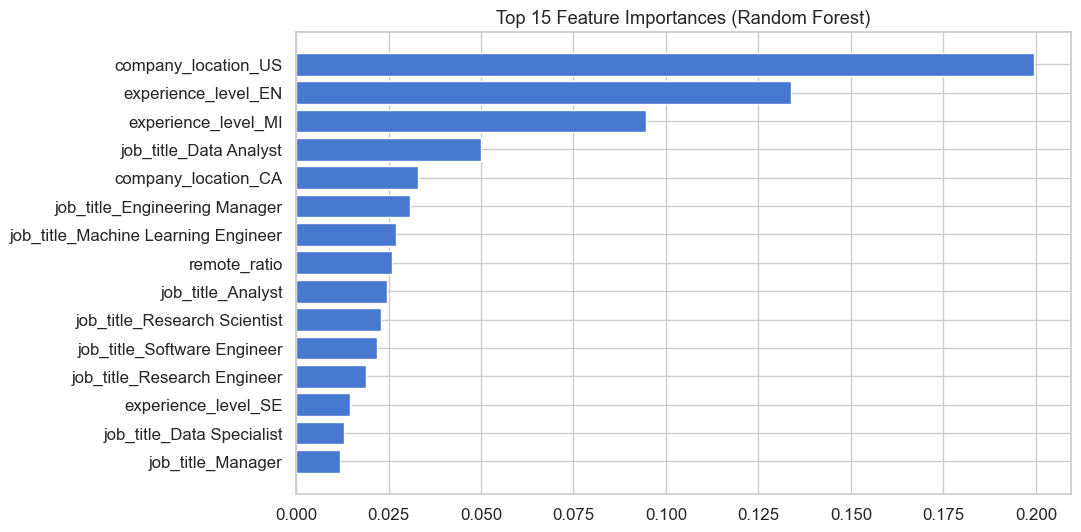

In [ ]:
import matplotlib.pyplot as plt

# Get feature names from one-hot encoder
onehot_features = list(linreg.named_steps['preprocessor']
                       .transformers_[0][1]
                       .get_feature_names_out(cat_cols))

all_features = onehot_features + num_cols

# Feature importances from Random Forest
importances = rf.named_steps['model'].feature_importances_

# Sort and plot top 15
indices = np.argsort(importances)[-15:]
plt.figure(figsize=(10,6))
plt.barh(np.array(all_features)[indices], importances[indices])
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()

# Step 4: NLP – Analyzing Job Descriptions and Skills

In this step, we apply **Natural Language Processing (NLP)** techniques to analyze job titles and descriptions:
- Identify most common and emerging skills.
- Cluster job titles into meaningful groups.
- Track frequency of hot keywords (LLMs, Generative AI, MLOps).
- Visualize word clouds and keyword trends.

This complements salary modeling by showing **why some jobs/skills pay more**.

In [ ]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Clean job titles/descriptions
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)   # keep only letters
    return text

df['job_title_clean'] = df['job_title'].apply(clean_text)

ModuleNotFoundError: No module named 'wordcloud'

In [ ]:
text = " ".join(df['job_title_clean'])
wc = WordCloud(width=1000, height=500, background_color="white").generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Job Titles/Skills (Word Cloud)")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
import pandas as pd

# --------------------------
# 1. Deduplicate job titles
# --------------------------
unique_jobs = df[['job_title']].drop_duplicates().reset_index(drop=True)

# Clean job titles
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)   # keep only letters
    return text.strip()

unique_jobs['job_title_clean'] = unique_jobs['job_title'].apply(clean_text)

# --------------------------
# 2. TF-IDF vectorization
# --------------------------
vectorizer = TfidfVectorizer(stop_words='english')
X_tfidf = vectorizer.fit_transform(unique_jobs['job_title_clean'])

# --------------------------
# 3. Dimensionality reduction (optional, makes clustering smoother)
# --------------------------
svd = TruncatedSVD(n_components=20, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

# --------------------------
# 4. KMeans clustering
# --------------------------
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
unique_jobs['job_cluster'] = kmeans.fit_predict(X_reduced)

# --------------------------
# 5. Preview clusters
# --------------------------
print(unique_jobs.groupby('job_cluster')['job_title'].apply(list).head())

In [ ]:
keywords = ['llm', 'generative ai', 'mlops', 'cloud', 'python', 'transformer']

for kw in keywords:
    df[kw] = df['job_title_clean'].str.contains(kw, regex=False)

trend = df.groupby('work_year')[keywords].mean() * 100  # % of postings with keyword

trend.plot(kind='line', marker='o', figsize=(10,6))
plt.title("Keyword Trends in Job Titles (2020–2025)")
plt.ylabel("% of job postings mentioning keyword")
plt.show()

In [ ]:
skill_salary = {}
for kw in keywords:
    avg_salary = df[df[kw]==True]['salary_in_usd'].mean()
    skill_salary[kw] = avg_salary

pd.Series(skill_salary).sort_values(ascending=False).plot(kind='barh', figsize=(8,5))
plt.title("Average Salaries for Jobs Mentioning Key Skills")
plt.xlabel("Avg Salary (USD)")
plt.show()
